# Week 7 Extension: Dyna-Q, Dyna-Q+, and Prioritized Sweeping on Taxi-v3

This notebook extends the original Week 7 planning-and-learning notebook from simple grid examples to **Gymnasium's Taxi-v3** environment.

The implementation includes:

1. **Pure Q-learning** as the model-free baseline (`n = 0`)
2. **Dyna-Q** with uniform random planning (`n ∈ {5, 10, 50}`)
3. **Dynamic Taxi wrapper** that changes the transition structure after 1000 real time steps
4. **Dyna-Q+** with exploration bonus `κ√τ`
5. **Prioritized sweeping** using Python's `heapq`
6. Visual comparisons for cumulative reward, sample efficiency, adaptation, and learning speed
7. A final synthesis discussing model-based vs. model-free methods

The code uses **NumPy Q-tables** and **Python dictionaries** for the learned model, matching the assignment requirements.

In [1]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import heapq
import random
import warnings
warnings.filterwarnings("ignore")

try:
    import gymnasium as gym
except ImportError as e:
    raise ImportError(
        "This notebook requires gymnasium. Install it with: pip install gymnasium[toy-text]"
    ) from e

%matplotlib inline

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

print("NumPy:", np.__version__)
print("Gymnasium:", gym.__version__)

NumPy: 2.4.2
Gymnasium: 1.2.3


## 1. Environment Setup: Taxi-v3

Taxi-v3 is a small tabular MDP with:

- **500 discrete states**
- **6 discrete actions**
  - `0 = south`
  - `1 = north`
  - `2 = east`
  - `3 = west`
  - `4 = pickup`
  - `5 = dropoff`
- **Reward structure**
  - `+20` for successful passenger dropoff
  - `-1` per time step
  - `-10` for illegal pickup or dropoff
- **Termination**
  - Episode ends after a correct dropoff or after truncation by the environment time limit

This makes Taxi-v3 a good fit for tabular Dyna-Q because the state-action space is small enough for a NumPy Q-table and a dictionary model.

In [2]:
def make_taxi(seed=42):
    env = gym.make("Taxi-v3")
    env.reset(seed=seed)
    env.action_space.seed(seed)
    return env

base_env = make_taxi(GLOBAL_SEED)
n_states = base_env.observation_space.n
n_actions = base_env.action_space.n

print("States:", n_states)
print("Actions:", n_actions)

States: 500
Actions: 6


## 2. Shared Helper Functions

These helpers are reused across Q-learning, Dyna-Q, Dyna-Q+, and prioritized sweeping.

The core Q-learning update is:

\[
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'}Q(s',a') - Q(s,a)\right]
\]

For terminal states, the target uses only the reward.

In [3]:
def epsilon_greedy(Q, state, epsilon, rng):
    """Choose an action using epsilon-greedy exploration."""
    if rng.random() < epsilon:
        return int(rng.integers(Q.shape[1]))
    return int(np.argmax(Q[state]))


def q_learning_update(Q, s, a, r, s_next, done, alpha, gamma):
    """One tabular Q-learning update. Returns absolute TD error for diagnostics."""
    best_next = 0.0 if done else np.max(Q[s_next])
    td_target = r + gamma * best_next
    td_error = td_target - Q[s, a]
    Q[s, a] += alpha * td_error
    return abs(td_error)


def moving_average(x, window=50):
    """Simple moving average with same output length."""
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return x
    if len(x) < window:
        return np.full_like(x, np.mean(x), dtype=float)
    kernel = np.ones(window) / window
    smooth = np.convolve(x, kernel, mode="valid")
    pad = np.full(window - 1, smooth[0])
    return np.concatenate([pad, smooth])


def greedy_evaluate(make_env_fn, Q, episodes=20, max_steps=200, seed=123):
    """Evaluate a greedy policy without exploration."""
    returns, steps_list, successes = [], [], []
    for ep in range(episodes):
        env = make_env_fn(seed + ep)
        state, _ = env.reset(seed=seed + ep)
        total = 0
        for t in range(max_steps):
            action = int(np.argmax(Q[state]))
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
            state = next_state
            if done:
                break
        returns.append(total)
        steps_list.append(t + 1)
        successes.append(total > 0)
        env.close()
    return {
        "mean_return": float(np.mean(returns)),
        "mean_steps": float(np.mean(steps_list)),
        "success_rate": float(np.mean(successes)),
    }


def summarize_threshold(result, return_threshold=8.0, eval_window=10):
    """Find first real step where recent evaluation return crosses threshold."""
    eval_steps = np.array(result["eval_steps"])
    eval_returns = np.array(result["eval_returns"])
    if len(eval_returns) < eval_window:
        return None
    smoothed = moving_average(eval_returns, eval_window)
    hits = np.where(smoothed >= return_threshold)[0]
    if len(hits) == 0:
        return None
    return int(eval_steps[hits[0]])

## 3. Dyna-Q Implementation

Dyna-Q integrates three processes inside one loop:

1. **Direct RL**: update Q from a real environment transition.
2. **Model learning**: store the observed transition in a dictionary.
3. **Planning**: sample previously observed state-action pairs from the model and perform simulated Q-learning updates.

The assignment specifies `model[(s,a)] = (r, s')`. In this notebook, the model stores `(r, s_next, done)` so terminal transitions are handled correctly while preserving the same table-based idea.

In [4]:
def run_dyna_q(
    make_env_fn,
    planning_steps=0,
    episodes=500,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    max_steps_per_episode=200,
    seed=42,
    eval_every=25,
    eval_episodes=20,
):
    """
    Run Q-learning or Dyna-Q on Taxi-v3.

    planning_steps = 0 gives pure model-free Q-learning.
    planning_steps > 0 gives Dyna-Q with uniform random planning.
    """
    rng = np.random.default_rng(seed)
    env = make_env_fn(seed)
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions), dtype=float)
    model = {}  # model[(s,a)] = (r, s_next, done)

    episode_returns = []
    episode_steps = []
    cumulative_rewards = []
    real_step_axis = []
    eval_steps = []
    eval_returns = []

    total_real_steps = 0
    cumulative_reward = 0

    for ep in range(episodes):
        state, _ = env.reset(seed=seed + ep)
        ep_return = 0

        for t in range(max_steps_per_episode):
            action = epsilon_greedy(Q, state, epsilon, rng)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # 1. Direct RL update from real experience
            q_learning_update(Q, state, action, reward, next_state, done, alpha, gamma)

            # 2. Model learning
            model[(state, action)] = (reward, next_state, done)

            # 3. Planning updates from simulated experience
            if planning_steps > 0 and len(model) > 0:
                keys = list(model.keys())
                for _ in range(planning_steps):
                    sim_s, sim_a = keys[int(rng.integers(len(keys)))]
                    sim_r, sim_next, sim_done = model[(sim_s, sim_a)]
                    q_learning_update(Q, sim_s, sim_a, sim_r, sim_next, sim_done, alpha, gamma)

            total_real_steps += 1
            cumulative_reward += reward
            ep_return += reward
            cumulative_rewards.append(cumulative_reward)
            real_step_axis.append(total_real_steps)

            state = next_state
            if done:
                break

        episode_returns.append(ep_return)
        episode_steps.append(t + 1)

        if (ep + 1) % eval_every == 0:
            metrics = greedy_evaluate(make_env_fn, Q, episodes=eval_episodes, seed=seed + 10_000 + ep)
            eval_steps.append(total_real_steps)
            eval_returns.append(metrics["mean_return"])

    env.close()
    return {
        "Q": Q,
        "model": model,
        "episode_returns": np.array(episode_returns),
        "episode_steps": np.array(episode_steps),
        "cumulative_rewards": np.array(cumulative_rewards),
        "real_step_axis": np.array(real_step_axis),
        "eval_steps": np.array(eval_steps),
        "eval_returns": np.array(eval_returns),
        "total_real_steps": total_real_steps,
    }

## 4. Experiment 1: Pure Q-learning vs. Dyna-Q

We compare:

- `n = 0`: pure Q-learning
- `n = 5`: Dyna-Q with 5 planning updates per real step
- `n = 10`: Dyna-Q with 10 planning updates per real step
- `n = 50`: Dyna-Q with 50 planning updates per real step

The main question is whether more planning reduces the number of **real environment interactions** needed to learn a good policy.

In [5]:
# Experiment settings
planning_values = [0, 5, 10, 50]
results = {}

for n in planning_values:
    print(f"Running Dyna-Q with n={n} planning steps...")
    results[n] = run_dyna_q(
        make_env_fn=make_taxi,
        planning_steps=n,
        episodes=500,
        alpha=0.1,
        gamma=0.95,
        epsilon=0.1,
        max_steps_per_episode=200,
        seed=GLOBAL_SEED + n,
        eval_every=25,
        eval_episodes=20,
    )

print("Done.")

Running Dyna-Q with n=0 planning steps...
Running Dyna-Q with n=5 planning steps...
Running Dyna-Q with n=10 planning steps...
Running Dyna-Q with n=50 planning steps...
Done.


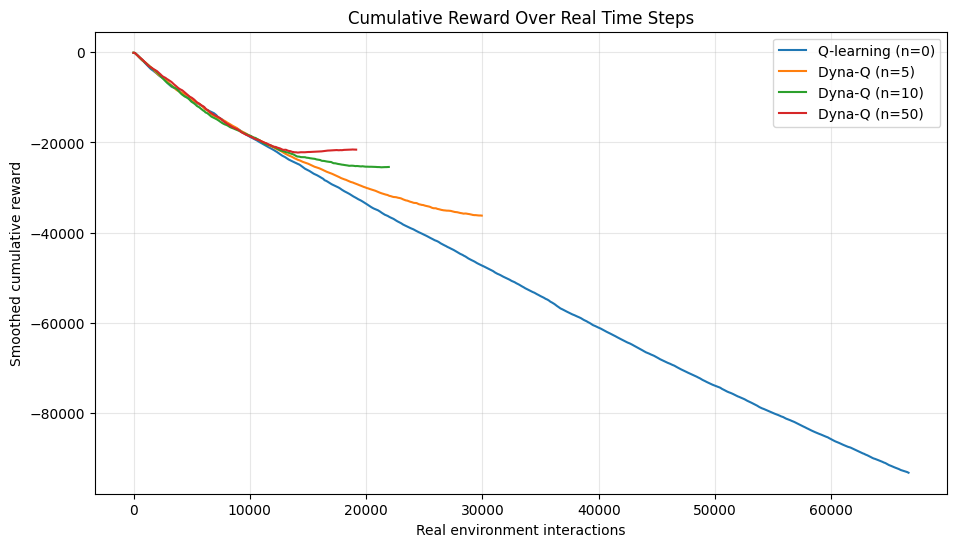

In [6]:
# Visualization 1: cumulative reward over real environment time steps
plt.figure(figsize=(11, 6))

for n, result in results.items():
    x = result["real_step_axis"]
    y = moving_average(result["cumulative_rewards"], window=100)
    label = "Q-learning (n=0)" if n == 0 else f"Dyna-Q (n={n})"
    plt.plot(x, y, label=label)

plt.xlabel("Real environment interactions")
plt.ylabel("Smoothed cumulative reward")
plt.title("Cumulative Reward Over Real Time Steps")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

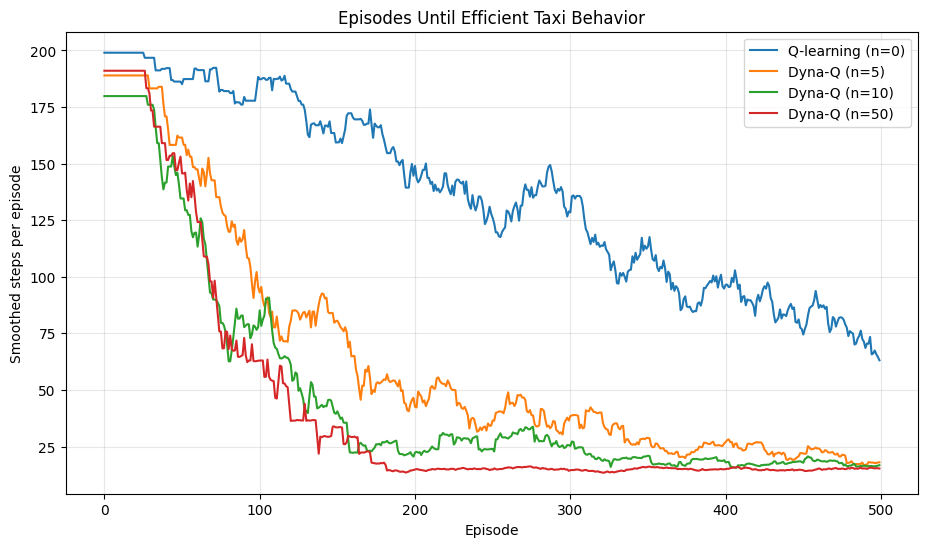

In [7]:
# Visualization 2: episode length / steps-to-completion over episodes
plt.figure(figsize=(11, 6))

for n, result in results.items():
    y = moving_average(result["episode_steps"], window=25)
    label = "Q-learning (n=0)" if n == 0 else f"Dyna-Q (n={n})"
    plt.plot(y, label=label)

plt.xlabel("Episode")
plt.ylabel("Smoothed steps per episode")
plt.title("Episodes Until Efficient Taxi Behavior")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
# Visualization 3: sample efficiency table
sample_efficiency = []

for n, result in results.items():
    steps_to_threshold = summarize_threshold(result, return_threshold=8.0, eval_window=3)
    final_eval = result["eval_returns"][-1] if len(result["eval_returns"]) else np.nan
    final_steps = moving_average(result["episode_steps"], window=25)[-1]
    sample_efficiency.append({
        "method": "Q-learning" if n == 0 else f"Dyna-Q n={n}",
        "planning_steps": n,
        "real_steps_to_eval_return_>=8": steps_to_threshold,
        "final_eval_return": round(float(final_eval), 2),
        "final_smoothed_episode_steps": round(float(final_steps), 2),
        "model_size": len(result["model"]),
    })

sample_efficiency

[{'method': 'Q-learning',
  'planning_steps': 0,
  'real_steps_to_eval_return_>=8': None,
  'final_eval_return': -178.65,
  'final_smoothed_episode_steps': 63.12,
  'model_size': 2400},
 {'method': 'Dyna-Q n=5',
  'planning_steps': 5,
  'real_steps_to_eval_return_>=8': None,
  'final_eval_return': -74.4,
  'final_smoothed_episode_steps': 18.04,
  'model_size': 2396},
 {'method': 'Dyna-Q n=10',
  'planning_steps': 10,
  'real_steps_to_eval_return_>=8': None,
  'final_eval_return': 8.45,
  'final_smoothed_episode_steps': 16.76,
  'model_size': 2379},
 {'method': 'Dyna-Q n=50',
  'planning_steps': 50,
  'real_steps_to_eval_return_>=8': 15385,
  'final_eval_return': 6.95,
  'final_smoothed_episode_steps': 15.32,
  'model_size': 2367}]

**Interpretation guide.**  
A lower value in `real_steps_to_eval_return_>=8` means the method reached good performance with fewer real interactions. Dyna-Q should usually improve sample efficiency because each real transition can be reused many times during planning. However, very large `n` can add computation and may not always produce proportional improvement.

## 5. Dynamic Taxi Environment

To test adaptation, this wrapper changes the environment after 1000 real steps.

Instead of rewriting Taxi-v3's internal transition table, the wrapper adds a new structural rule after the change point:

> After `change_step`, a new wall blocks east/west movement across a selected boundary.  
> If the taxi tries to cross that boundary, the taxi remains in the same state and receives the normal step penalty.

This creates a non-stationary environment: transitions that were previously valid become invalid after the change.

In [9]:
class DynamicTaxiWallWrapper(gym.Wrapper):
    """
    Taxi-v3 wrapper with a dynamic wall introduced after change_step real steps.

    The wall blocks:
    - east from (row=2, col=2)
    - west from (row=2, col=3)

    This changes the transition structure while preserving the original Taxi reward logic.
    """
    def __init__(self, env, change_step=1000):
        super().__init__(env)
        self.change_step = change_step
        self.global_step = 0
        self.changed = False

    def reset(self, **kwargs):
        return self.env.reset(**kwargs)

    def step(self, action):
        state_before = self.unwrapped.s
        taxi_row, taxi_col, pass_loc, dest_idx = self.unwrapped.decode(state_before)

        self.global_step += 1
        if self.global_step >= self.change_step:
            self.changed = True

        # Dynamic wall condition: block one east/west corridor after change point
        blocked_east = self.changed and action == 2 and taxi_row == 2 and taxi_col == 2
        blocked_west = self.changed and action == 3 and taxi_row == 2 and taxi_col == 3

        if blocked_east or blocked_west:
            # Stay in same state with normal step penalty.
            reward = -1
            terminated = False
            truncated = False
            info = {"dynamic_wall": True, "changed": self.changed}
            return state_before, reward, terminated, truncated, info

        next_state, reward, terminated, truncated, info = self.env.step(action)
        info["changed"] = self.changed
        return next_state, reward, terminated, truncated, info


def make_dynamic_taxi(seed=42, change_step=1000):
    env = gym.make("Taxi-v3")
    env.reset(seed=seed)
    env.action_space.seed(seed)
    return DynamicTaxiWallWrapper(env, change_step=change_step)

## 6. Dyna-Q+ Implementation

Dyna-Q+ addresses changing environments by adding an exploration bonus during planning:

\[
r_{bonus} = r + \kappa \sqrt{\tau}
\]

where `τ` is the number of real time steps since the state-action pair was last tried. This encourages the agent to revisit actions that may have changed.

In [10]:
def run_dyna_q_plus(
    make_env_fn,
    planning_steps=10,
    episodes=500,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    kappa=0.001,
    max_steps_per_episode=200,
    seed=42,
):
    """Run Dyna-Q+ with exploration bonus during planning."""
    rng = np.random.default_rng(seed)
    env = make_env_fn(seed)
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions), dtype=float)
    model = {}          # model[(s,a)] = (r, s_next, done)
    last_visit = {}     # last real time step when (s,a) was tried

    episode_returns = []
    episode_steps = []
    cumulative_rewards = []
    real_step_axis = []
    change_flags = []

    total_real_steps = 0
    cumulative_reward = 0

    for ep in range(episodes):
        state, _ = env.reset(seed=seed + ep)
        ep_return = 0

        for t in range(max_steps_per_episode):
            # Dyna-Q+ adds default self-loop model entries for all actions of visited states
            for a in range(n_actions):
                if (state, a) not in model:
                    model[(state, a)] = (0.0, state, False)
                    last_visit[(state, a)] = total_real_steps

            action = epsilon_greedy(Q, state, epsilon, rng)

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Direct real update uses actual reward only, no exploration bonus
            q_learning_update(Q, state, action, reward, next_state, done, alpha, gamma)

            # Model learning
            model[(state, action)] = (reward, next_state, done)
            last_visit[(state, action)] = total_real_steps

            # Planning with bonus
            keys = list(model.keys())
            for _ in range(planning_steps):
                sim_s, sim_a = keys[int(rng.integers(len(keys)))]
                sim_r, sim_next, sim_done = model[(sim_s, sim_a)]
                tau = total_real_steps - last_visit.get((sim_s, sim_a), 0)
                bonus = kappa * np.sqrt(max(tau, 0))
                q_learning_update(Q, sim_s, sim_a, sim_r + bonus, sim_next, sim_done, alpha, gamma)

            total_real_steps += 1
            cumulative_reward += reward
            ep_return += reward
            cumulative_rewards.append(cumulative_reward)
            real_step_axis.append(total_real_steps)
            change_flags.append(bool(info.get("changed", False)))

            state = next_state
            if done:
                break

        episode_returns.append(ep_return)
        episode_steps.append(t + 1)

    env.close()
    return {
        "Q": Q,
        "model": model,
        "episode_returns": np.array(episode_returns),
        "episode_steps": np.array(episode_steps),
        "cumulative_rewards": np.array(cumulative_rewards),
        "real_step_axis": np.array(real_step_axis),
        "change_flags": np.array(change_flags),
        "total_real_steps": total_real_steps,
    }

## 7. Experiment 2: Dyna-Q vs. Dyna-Q+ After Dynamic Change

Both methods receive 10 planning steps per real step. The difference is that Dyna-Q+ receives the `κ√τ` exploration bonus during planning.

After the transition change, Dyna-Q may keep relying on stale model entries. Dyna-Q+ should recover faster because untried actions gain value through the exploration bonus.

In [11]:
dynamic_change_step = 1000

regular_dynamic = run_dyna_q(
    make_env_fn=lambda seed: make_dynamic_taxi(seed, change_step=dynamic_change_step),
    planning_steps=10,
    episodes=500,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    max_steps_per_episode=200,
    seed=2026,
    eval_every=50,
    eval_episodes=10,
)

plus_dynamic = run_dyna_q_plus(
    make_env_fn=lambda seed: make_dynamic_taxi(seed, change_step=dynamic_change_step),
    planning_steps=10,
    episodes=500,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    kappa=0.001,
    max_steps_per_episode=200,
    seed=2026,
)

print("Regular Dyna-Q real steps:", regular_dynamic["total_real_steps"])
print("Dyna-Q+ real steps:", plus_dynamic["total_real_steps"])

Regular Dyna-Q real steps: 28924
Dyna-Q+ real steps: 28684


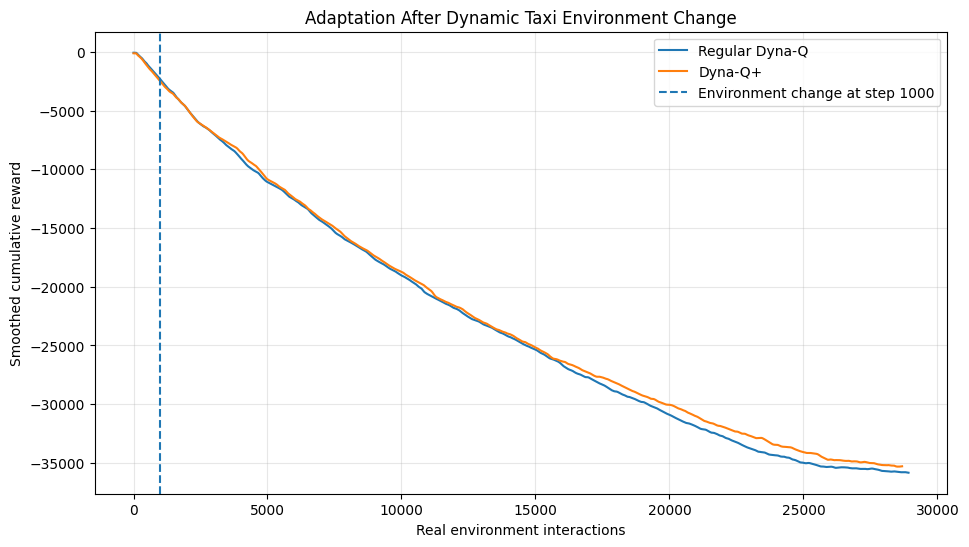

In [12]:
plt.figure(figsize=(11, 6))

plt.plot(
    regular_dynamic["real_step_axis"],
    moving_average(regular_dynamic["cumulative_rewards"], 100),
    label="Regular Dyna-Q"
)

plt.plot(
    plus_dynamic["real_step_axis"],
    moving_average(plus_dynamic["cumulative_rewards"], 100),
    label="Dyna-Q+"
)

plt.axvline(dynamic_change_step, linestyle="--", label="Environment change at step 1000")
plt.xlabel("Real environment interactions")
plt.ylabel("Smoothed cumulative reward")
plt.title("Adaptation After Dynamic Taxi Environment Change")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

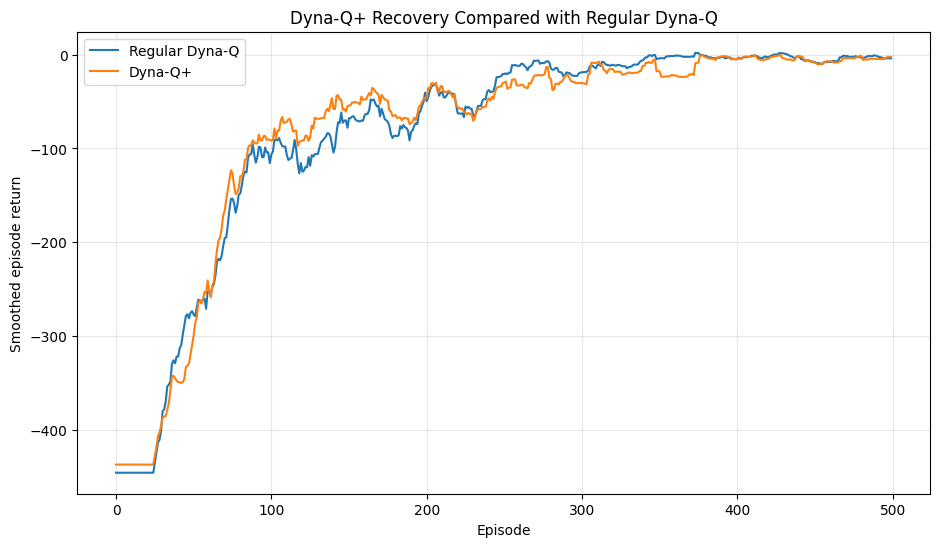

In [13]:
plt.figure(figsize=(11, 6))

plt.plot(moving_average(regular_dynamic["episode_returns"], 25), label="Regular Dyna-Q")
plt.plot(moving_average(plus_dynamic["episode_returns"], 25), label="Dyna-Q+")
plt.xlabel("Episode")
plt.ylabel("Smoothed episode return")
plt.title("Dyna-Q+ Recovery Compared with Regular Dyna-Q")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Prioritized Sweeping

Uniform Dyna-Q samples random model entries during planning. Prioritized sweeping focuses computation on state-action pairs with large expected TD error.

The priority is:

\[
p = \left|r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right|
\]

A max-priority queue is implemented using Python's `heapq` by storing negative priorities.

In [14]:
def run_prioritized_sweeping(
    make_env_fn,
    planning_steps=10,
    episodes=500,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    theta=1e-5,
    max_steps_per_episode=200,
    seed=42,
):
    """Prioritized sweeping for deterministic tabular environments."""
    rng = np.random.default_rng(seed)
    env = make_env_fn(seed)
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions), dtype=float)
    model = {}  # model[(s,a)] = (r, s_next, done)
    predecessors = defaultdict(set)  # predecessors[s_next].add((s,a))
    priority_queue = []
    queued = set()

    episode_returns = []
    episode_steps = []
    cumulative_rewards = []
    real_step_axis = []
    total_real_steps = 0
    cumulative_reward = 0

    def push_priority(s, a):
        if (s, a) not in model:
            return
        r, s_next, done = model[(s, a)]
        best_next = 0.0 if done else np.max(Q[s_next])
        priority = abs(r + gamma * best_next - Q[s, a])
        if priority > theta:
            heapq.heappush(priority_queue, (-priority, s, a))
            queued.add((s, a))

    for ep in range(episodes):
        state, _ = env.reset(seed=seed + ep)
        ep_return = 0

        for t in range(max_steps_per_episode):
            action = epsilon_greedy(Q, state, epsilon, rng)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Store deterministic model and predecessors
            model[(state, action)] = (reward, next_state, done)
            predecessors[next_state].add((state, action))

            # Push observed pair according to expected TD error
            push_priority(state, action)

            # Planning from highest-priority entries
            for _ in range(planning_steps):
                if not priority_queue:
                    break

                _, sim_s, sim_a = heapq.heappop(priority_queue)
                queued.discard((sim_s, sim_a))

                sim_r, sim_next, sim_done = model[(sim_s, sim_a)]
                q_learning_update(Q, sim_s, sim_a, sim_r, sim_next, sim_done, alpha, gamma)

                # Add predecessors of sim_s if their priority is large enough
                for pred_s, pred_a in predecessors[sim_s]:
                    push_priority(pred_s, pred_a)

            total_real_steps += 1
            cumulative_reward += reward
            ep_return += reward
            cumulative_rewards.append(cumulative_reward)
            real_step_axis.append(total_real_steps)

            state = next_state
            if done:
                break

        episode_returns.append(ep_return)
        episode_steps.append(t + 1)

    env.close()
    return {
        "Q": Q,
        "model": model,
        "episode_returns": np.array(episode_returns),
        "episode_steps": np.array(episode_steps),
        "cumulative_rewards": np.array(cumulative_rewards),
        "real_step_axis": np.array(real_step_axis),
        "total_real_steps": total_real_steps,
    }

## 9. Experiment 3: Uniform Planning vs. Prioritized Sweeping

Both methods use 10 planning steps per real step. The comparison asks whether planning is more useful when it is directed toward transitions with large TD error.

In [15]:
uniform_n10 = results[10]

priority_n10 = run_prioritized_sweeping(
    make_env_fn=make_taxi,
    planning_steps=10,
    episodes=500,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    theta=1e-5,
    max_steps_per_episode=200,
    seed=777,
)

print("Uniform Dyna-Q model size:", len(uniform_n10["model"]))
print("Prioritized sweeping model size:", len(priority_n10["model"]))

Uniform Dyna-Q model size: 2379
Prioritized sweeping model size: 2383


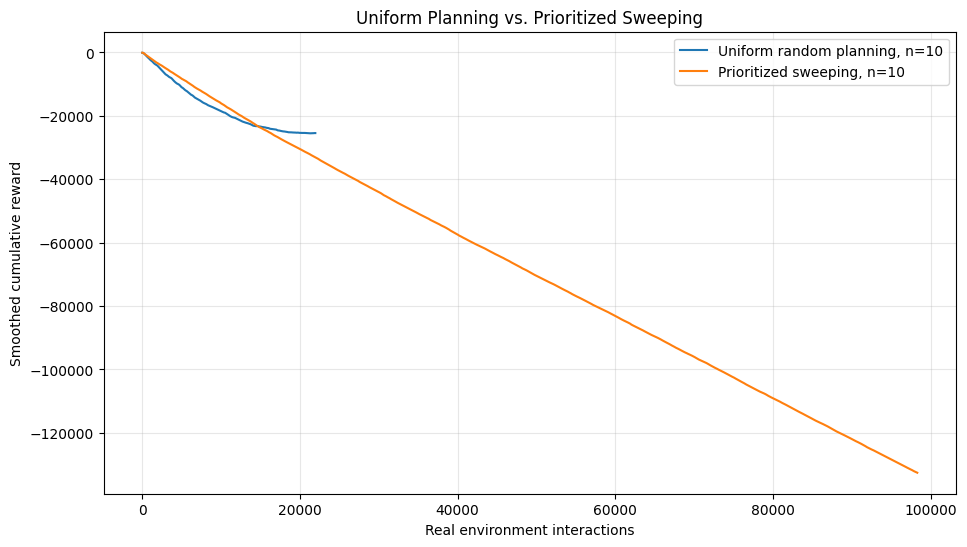

In [16]:
plt.figure(figsize=(11, 6))

plt.plot(
    uniform_n10["real_step_axis"],
    moving_average(uniform_n10["cumulative_rewards"], 100),
    label="Uniform random planning, n=10"
)

plt.plot(
    priority_n10["real_step_axis"],
    moving_average(priority_n10["cumulative_rewards"], 100),
    label="Prioritized sweeping, n=10"
)

plt.xlabel("Real environment interactions")
plt.ylabel("Smoothed cumulative reward")
plt.title("Uniform Planning vs. Prioritized Sweeping")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

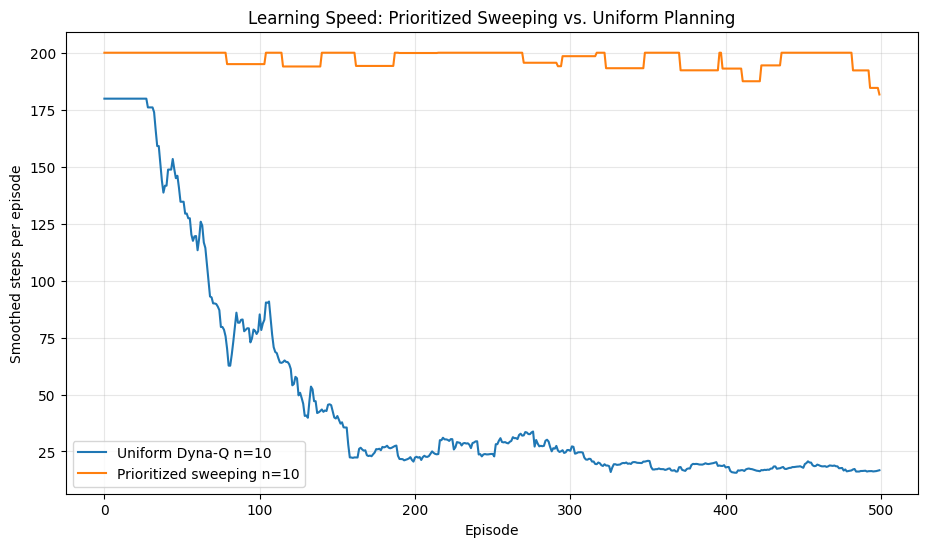

In [17]:
plt.figure(figsize=(11, 6))

plt.plot(moving_average(uniform_n10["episode_steps"], 25), label="Uniform Dyna-Q n=10")
plt.plot(moving_average(priority_n10["episode_steps"], 25), label="Prioritized sweeping n=10")

plt.xlabel("Episode")
plt.ylabel("Smoothed steps per episode")
plt.title("Learning Speed: Prioritized Sweeping vs. Uniform Planning")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Final Synthesis

### When should we use model-based vs. model-free methods?

Model-free methods such as pure Q-learning are useful when the environment is difficult to model, very large, stochastic in complicated ways, or when the computational budget for planning is limited. They learn directly from real experience and do not need to store or simulate transitions. However, this also means that every improvement depends on additional environment interaction.

Model-based methods such as Dyna-Q are useful when real experience is expensive but computation is relatively cheap. In Taxi-v3, every real transition can be stored in a dictionary model and reused many times through planning. This makes Dyna-Q more sample efficient than pure Q-learning because the agent learns both from real experience and from simulated experience.

### How does sample complexity compare?

Pure Q-learning uses each real transition once. Dyna-Q uses each real transition once directly and then can reuse remembered transitions during planning. Therefore, Dyna-Q generally needs fewer real environment interactions to reach a good policy. In the sample-efficiency table above, this appears as fewer real steps needed to cross the evaluation-return threshold. The tradeoff is that Dyna-Q performs more computation per real step.

### What are the computational trade-offs?

Planning is not free. If `n=50`, the agent performs fifty simulated Q-updates after every real step. This may reduce real sample complexity, but it increases wall-clock computation. If the environment is cheap to sample, pure Q-learning may be simpler and fast enough. If real interactions are expensive, risky, or slow, planning can be worth the extra computation.

Prioritized sweeping improves this trade-off by planning where updates are most needed. Instead of sampling random model entries, it uses a priority queue to focus simulated updates on state-action pairs with large TD errors. This can improve learning speed because updates are directed toward transitions that are expected to change the value function the most.

### How do model errors affect performance?

The main weakness of model-based methods is that the model can become wrong. In the dynamic Taxi experiment, the environment changes after 1000 real steps. Regular Dyna-Q may continue planning with stale transitions until enough real experience corrects the model. Dyna-Q+ handles this problem better by adding an exploration bonus to actions that have not been tried recently. This encourages the agent to re-check old assumptions and adapt more quickly after the environment changes.

### Overall conclusion

Dyna-style methods show the value of integrating learning, model building, and planning. Pure Q-learning is simpler and avoids model error, but it is less sample efficient. Dyna-Q improves sample efficiency by reusing experience. Dyna-Q+ is better suited for changing environments because it encourages renewed exploration. Prioritized sweeping improves computational efficiency by replacing random planning with focused planning based on TD-error priority.